In [5]:
!pip install -q diffusers transformers accelerate

In [6]:
# Import libraries
import torch
from diffusers import StableDiffusionPipeline
import pandas as pd
import os
from PIL import Image

# Check GPU availability
print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


GPU Available: True
GPU Name: Tesla T4


In [7]:
# Create folders for storing generated images and results
folders = [
    'generated_images/vanilla',
    'generated_images/structured',
    'generated_images/rejection_5',
    'generated_images/rejection_10',
    'generated_images/feedback',
    'generated_images/test',
    'results'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [12]:
# Login to Hugging Face to download models
from huggingface_hub import login

# You will be prompted to enter a token
login()

In [11]:
# Load Stable Diffusion v1.5 model (more stable and widely available)
print("Loading Stable Diffusion 1.5...")

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda")

print("Model loaded successfully!")

Loading Stable Diffusion 1.5...


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully!


Generating test image...


  0%|          | 0/50 [00:00<?, ?it/s]

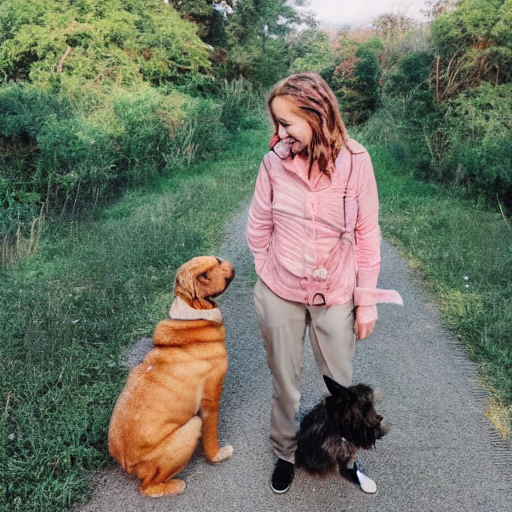

Test image generated successfully!


In [13]:
# Generate a test image to verify everything works
print("Generating test image...")

test_prompt = "a person and a dog"

image = pipe(
    test_prompt,
    num_inference_steps=50,
    guidance_scale=7.5,
    height=512,
    width=512
).images[0]

# Save the test image
image.save("generated_images/test/first_test.png")

# Display the image
display(image)

print("Test image generated successfully!")

In [14]:
# Load the prompts from CSV file
prompts_df = pd.read_csv('prompts.csv')

# Display first few rows to verify
print(f"Loaded {len(prompts_df)} prompts")
print("\nFirst 5 prompts:")
print(prompts_df.head())

Loaded 30 prompts

First 5 prompts:
   prompt_id                   prompt_text  num_objects        object_list  \
0          1            a person and a dog            2         person|dog   
1          2      a cat sitting on a chair            2          cat|chair   
2          3       a bicycle next to a car            2        bicycle|car   
3          4  a laptop and a cup of coffee            2         laptop|cup   
4          5      a book on a dining table            2  book|dining table   

  complexity  
0     simple  
1     simple  
2     simple  
3     simple  
4     simple  


In [15]:
# Define the image generator class
class ImageGenerator:
    def __init__(self, pipeline):
        self.pipe = pipeline

    def generate(self, prompt, output_path, seed=None):
        # Set random seed if provided for reproducibility
        if seed is not None:
            generator = torch.Generator("cuda").manual_seed(seed)
        else:
            generator = None

        # Generate image
        image = self.pipe(
            prompt,
            generator=generator,
            num_inference_steps=50,
            guidance_scale=7.5,
            height=512,
            width=512
        ).images[0]

        # Create directory if it does not exist
        os.makedirs(os.path.dirname(output_path), exist_ok=True)

        # Save image
        image.save(output_path)

        return image

# Initialize the generator with loaded pipeline
generator = ImageGenerator(pipe)

print("Generator class created successfully!")

Generator class created successfully!


In [16]:
# Run vanilla baseline: generate 1 image per prompt with no modifications
print("=" * 60)
print("RUNNING VANILLA BASELINE")
print("=" * 60)

results = []

for idx, row in prompts_df.iterrows():
    prompt_id = row['prompt_id']
    prompt_text = row['prompt_text']

    print(f"\n[{idx+1}/{len(prompts_df)}] Prompt {prompt_id}: {prompt_text}")

    # Generate image
    output_path = f"generated_images/vanilla/prompt_{prompt_id:03d}.png"
    generator.generate(prompt_text, output_path, seed=42+prompt_id)

    # Record result
    results.append({
        'prompt_id': prompt_id,
        'prompt_text': prompt_text,
        'method': 'vanilla',
        'image_path': output_path,
        'num_generated': 1
    })

    print(f"  Saved: {output_path}")

# Save results to CSV
results_df = pd.DataFrame(results)
results_df.to_csv('results/vanilla_results.csv', index=False)

print("\n" + "=" * 60)
print(f"VANILLA BASELINE COMPLETE")
print(f"Generated {len(results)} images")
print(f"Results saved to: results/vanilla_results.csv")
print("=" * 60)

RUNNING VANILLA BASELINE

[1/30] Prompt 1: a person and a dog


  0%|          | 0/50 [00:00<?, ?it/s]

  Saved: generated_images/vanilla/prompt_001.png

[2/30] Prompt 2: a cat sitting on a chair


  0%|          | 0/50 [00:00<?, ?it/s]

  Saved: generated_images/vanilla/prompt_002.png

[3/30] Prompt 3: a bicycle next to a car


...

  Saved: generated_images/vanilla/prompt_028.png

[29/30] Prompt 29: a person with a dog a cat and a suitcase


  0%|          | 0/50 [00:00<?, ?it/s]

  Saved: generated_images/vanilla/prompt_029.png

[30/30] Prompt 30: a couch a vase a clock and a teddy bear in a living room


  0%|          | 0/50 [00:00<?, ?it/s]

  Saved: generated_images/vanilla/prompt_030.png

VANILLA BASELINE COMPLETE
Generated 30 images
Results saved to: results/vanilla_results.csv


In [17]:
# Run structured baseline: reformat prompts before generation
print("=" * 60)
print("RUNNING STRUCTURED PROMPT BASELINE")
print("=" * 60)

def structure_prompt(original_prompt, num_objects):
    # Convert number to word
    number_words = {2: "two", 3: "three", 4: "four", 5: "five"}
    num_word = number_words.get(num_objects, str(num_objects))

    # Create structured format
    structured = f"An image containing exactly {num_word} objects: {original_prompt}. Show all {num_word} clearly."
    return structured

results = []

for idx, row in prompts_df.iterrows():
    prompt_id = row['prompt_id']
    original_prompt = row['prompt_text']
    num_objects = row['num_objects']

    # Create structured version
    structured_prompt = structure_prompt(original_prompt, num_objects)

    print(f"\n[{idx+1}/{len(prompts_df)}] Prompt {prompt_id}")
    print(f"  Original: {original_prompt}")
    print(f"  Structured: {structured_prompt}")

    # Generate image
    output_path = f"generated_images/structured/prompt_{prompt_id:03d}.png"
    generator.generate(structured_prompt, output_path, seed=42+prompt_id)

    # Record result
    results.append({
        'prompt_id': prompt_id,
        'original_prompt': original_prompt,
        'structured_prompt': structured_prompt,
        'method': 'structured',
        'image_path': output_path,
        'num_generated': 1
    })

    print(f"  Saved: {output_path}")

# Save results to CSV
results_df = pd.DataFrame(results)
results_df.to_csv('results/structured_results.csv', index=False)

print("\n" + "=" * 60)
print(f"STRUCTURED BASELINE COMPLETE")
print(f"Generated {len(results)} images")
print(f"Results saved to: results/structured_results.csv")
print("=" * 60)

RUNNING STRUCTURED PROMPT BASELINE

[1/30] Prompt 1
  Original: a person and a dog
  Structured: An image containing exactly two objects: a person and a dog. Show all two clearly.


  0%|          | 0/50 [00:00<?, ?it/s]

  Saved: generated_images/structured/prompt_001.png

[2/30] Prompt 2
  Original: a cat sitting on a chair
  Structured: An image containing exactly two objects: a cat sitting on a chair. Show all two clearly.


  0%|          | 0/50 [00:00<?, ?it/s]

  Saved: generated_images/structured/prompt_002.png

[3/30] Prompt 3
  Original: a bicycle next to a car
  Structured: An image containing exactly two objects: a bicycle next to a car. Show all two clearly.


...

  Saved: generated_images/structured/prompt_028.png

[29/30] Prompt 29
  Original: a person with a dog a cat and a suitcase
  Structured: An image containing exactly four objects: a person with a dog a cat and a suitcase. Show all four clearly.


  0%|          | 0/50 [00:00<?, ?it/s]

  Saved: generated_images/structured/prompt_029.png

[30/30] Prompt 30
  Original: a couch a vase a clock and a teddy bear in a living room
  Structured: An image containing exactly four objects: a couch a vase a clock and a teddy bear in a living room. Show all four clearly.


  0%|          | 0/50 [00:00<?, ?it/s]

  Saved: generated_images/structured/prompt_030.png

STRUCTURED BASELINE COMPLETE
Generated 30 images
Results saved to: results/structured_results.csv


In [18]:
# Compress all results for download
import shutil

# Create zip of generated images
shutil.make_archive('generated_images', 'zip', 'generated_images')

# Create zip of results
shutil.make_archive('results', 'zip', 'results')

print("Files compressed!")
print("1. generated_images.zip")
print("2. results.zip")

Files compressed!
1. generated_images.zip
2. results.zip
